In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json
from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *

In [ ]:
from examples.case_studies.CITE_seq_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [13]:
len(labels), expression_data.shape, methylation_data.shape

(1490, (1490, 3042), (1490, 3042))

In [14]:
expression_data.min(), expression_data.max()

(nan, nan)

<Axes: >

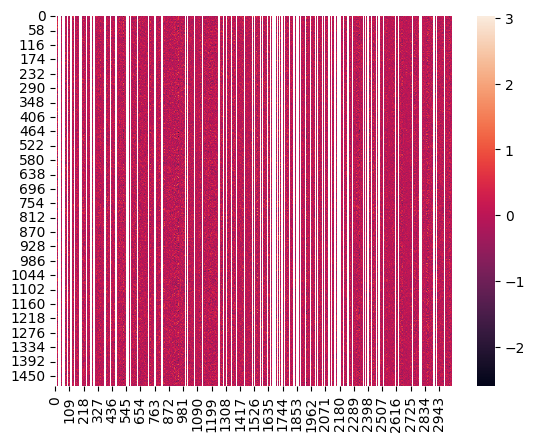

In [15]:
sns.heatmap(expression_data)

<Axes: >

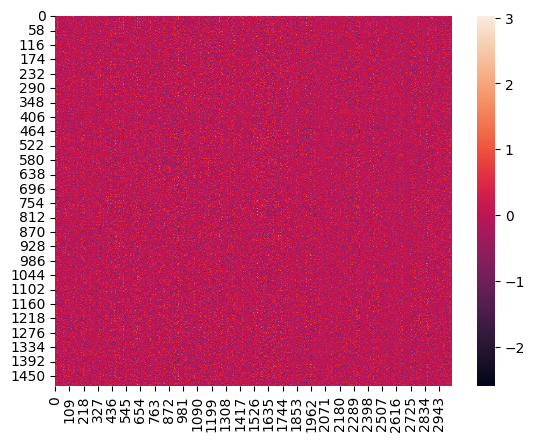

In [16]:
sns.heatmap(methylation_data)

In [17]:
methylation_data.min(), methylation_data.max()

(-2.597058304, 3.021236868)

In [18]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(np.abs(data) < 1e-5, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [19]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 3042
After remove all nan 2272
After remove all zeros 2272
Input #cols 3042
After remove all nan 3042
After remove all zeros 3042


In [20]:
np.any(np.abs(expression_data_clean) < 1e-5), np.any(np.abs(methylation_data_clean) < 1e-5)

(True, True)

In [21]:
expression_data_clean.min(), expression_data_clean.max()

(-2.596478527, 3.026596455)

In [22]:
methylation_data_clean.min(), methylation_data_clean.max()

(-2.597058304, 3.021236868)

Text(0.5, 1.0, 'methylation_data_clean')

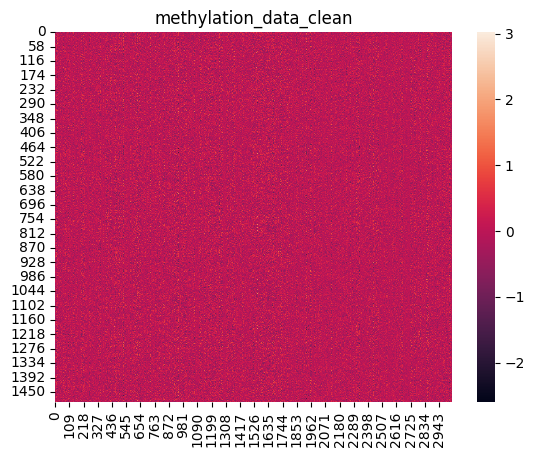

In [23]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

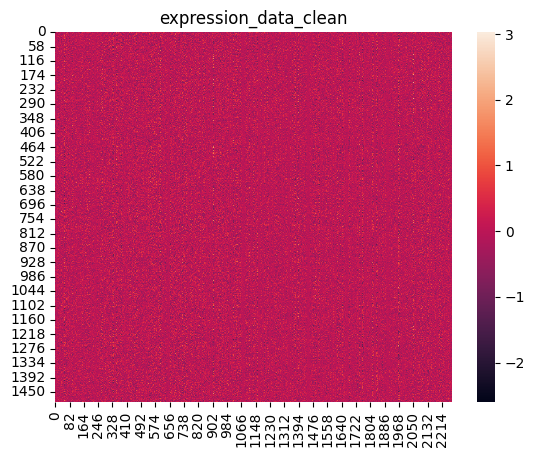

In [24]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [25]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [26]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [27]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3385165, 3), (3385165,), (4532421, 3), (4532421,))

In [28]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [29]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])
weights = np.exp(weights / 10)

In [30]:
weights.min(), weights.max()

(0.771278439105178, 1.3534537319723328)

In [31]:
np.any(np.abs(weights) < 1e-5)

False

In [32]:
edges.shape, weights.shape

((7917586, 3), (7917586,))

In [33]:
save_edges_and_weights('./data/SCoPE2', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [34]:
train_data = np.load('./data/SCoPE2/train_data.npz', allow_pickle=True)
test_data = np.load('./data/SCoPE2/test_data.npz', allow_pickle=True)

In [35]:
train_data['nums_type']

array([1490, 5314,    2])

Negative entries cannot be used. BUT WHY?

In [ ]:
!python hgnn/main_torch_zinb.py --data SCoPE2 --feature adj --loss bce --iter 4 --batch_size 96

1.0 -0.5
model_no_randomwalk
Use train_weight (6334068,)
Node type num [1490 5314    2]
embeddings_initial [False, False, False]
[1.0131531  1.0379957  0.975476   ... 1.0044416  0.99862033 1.026187  ] 0.77132314 1.3534538
walk type 
adding pad idx
dict_size 6334068 7917586
train data amount 6334068
64
tensor([   0, 1490, 6804, 6806], device='cuda:0')
w.shape (1490, 5316)
(1490, 5316)
w.shape (5314, 1492)
(5314, 1492)
w.shape (2, 6804)
(2, 6804)
self.input_size [5316, 1492, 6804]
inp 5316 out 64 weight.shape torch.Size([64, 5316])
fan_in 5316 72.91090453423274
inp 1492 out 64 weight.shape torch.Size([64, 1492])
fan_in 1492 38.62641583165593
inp 6804 out 64 weight.shape torch.Size([64, 6804])
fan_in 6804 82.48636250920512
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 MultipleEmbedding-1           [[-1, 64], [-1]]               0
         LayerNorm-2                [-1, 3, 64]    

In [ ]:
!ls -lh ./*.npy

-rw-r--r-- 1 congfeng4 mscs 373K Nov 10 19:09 ./mymodel_0.npy
-rw-r--r-- 1 congfeng4 mscs 373K Nov 10 19:09 ./mymodel_0_origin.npy
-rw-r--r-- 1 congfeng4 mscs 1.3M Nov 10 19:09 ./mymodel_1.npy
-rw-r--r-- 1 congfeng4 mscs 1.3M Nov 10 19:09 ./mymodel_1_origin.npy
-rw-r--r-- 1 congfeng4 mscs  640 Nov 10 19:09 ./mymodel_2.npy
-rw-r--r-- 1 congfeng4 mscs  640 Nov 10 19:09 ./mymodel_2_origin.npy


In [ ]:
!mkdir -p ./embeddings/hgnn/SCoPE2

In [ ]:
!mv *.npy ./embeddings/hgnn/SCoPE2

In [ ]:
cell_embeddings = np.load('./embeddings/hgnn/SCoPE2/mymodel_0.npy', allow_pickle=True)

In [ ]:
cell_embeddings.shape

(1490, 64)

/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


{'NMI': 0.0, 'ARI': 0.0, 'FMI': 0.7814893694215619}

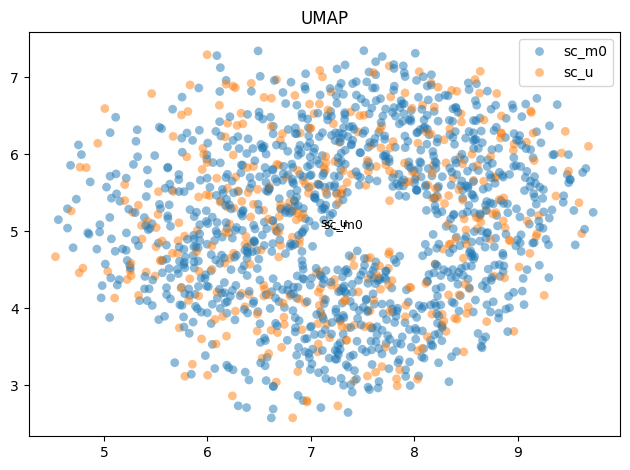

In [ ]:
umap_visualize(cell_embeddings, labels)